# Excitons and TDDFT: the bootstrap kernel

An absorption spectrum is the imaginary part of the macroscopic dielectric function as a
function of frequency, and getting it means building the independent-particle susceptibility
as a **matrix** over reciprocal lattice vectors,

$$\chi^0_{\mathbf{GG}'}(\omega)=\frac{1}{\Omega}\sum_{\mathbf k}\sum_{ij}
\frac{(f_i-f_j)\,\rho^{ij}_{\mathbf G}\rho^{ij*}_{\mathbf G'}}
{\epsilon_i-\epsilon_j+\omega+i\eta},
\qquad
\rho^{ij}_{\mathbf G}=\langle u_i|e^{-i\mathbf G\cdot\mathbf r}|u_j\rangle$$

and then solving the Dyson equation with an exchange-correlation kernel:

$$\epsilon^{-1}=1+X\left(1-X-\tilde f_{\rm xc}X\right)^{-1},\qquad X=v^{1/2}\chi^0v^{1/2}$$

**This is the one place in this package where a sum over empty states earns its keep.**
Everything in the linear-response stack produces $\chi_0$ as an *operator* from a Sternheimer
solve, which is cheaper and needs no empty bands -- but a spectrum needs the frequency axis
and needs $\chi_0$ as a matrix in two $\mathbf G$ indices, and neither is something an
operator gives.

The kernel decides whether the calculation can describe an **exciton**, a bound electron-hole
pair. The one used here is the **bootstrap** of Sharma, Dewhurst, Sanna and Gross
([PRL **107**, 186401 (2011)](https://doi.org/10.1103/PhysRevLett.107.186401)), which is a
fixed point of the Dyson equation and of its own definition: parameter-free, and converging
in a handful of passes.

| silicon, LDA, $4\times4\times4$ | |
|---|---|
| the bootstrap fixed point converges in | **9 passes** |
| its long-range strength $\alpha = -4\pi F_{00}$ | **+0.0232** |
| ALDA's, on the same $\chi_0$ | **0.0000, exactly** |
| band truncation of the sum, reported not tuned away | **-0.013** on a constant of about 22 |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.units import RY_TO_EV

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")
OMEGA = np.arange(0.0, 0.60, 0.004)      # Ry

silicon = Calculator.from_file(CASES / "si-epsilon-unshifted-nosym.in",
                               pseudo_dir=PSEUDO, announce=False)

The k-grid is unshifted, closed, and run under `nosym`. $\chi_0(\mathbf G, \mathbf G')$ is a
matrix in *two* $\mathbf G$ indices and symmetrising it would have to rotate both at once,
which nothing here does -- so this needs the **whole** grid, and an unshifted one is what
makes running it without symmetry sound in the first place.

Building $\chi_0$ is the whole cost and the kernel is nearly free, so the three spectra below
differ only in the Dyson equation solved on top of it.

In [2]:
spectra = {}
for kernel in ("rpa", "alda", "bootstrap"):
    spectra[kernel] = silicon.get_absorption(OMEGA, kernel=kernel, nbnd=60,
                                             ecut_response=8.0, broadening=0.012)

print("%-11s %9s %8s %12s" % ("kernel", "alpha", "passes", "truncation"))
for kernel, spectrum in spectra.items():
    print("%-11s %+9.4f %8d %12.4f"
          % (kernel, spectrum.alpha, spectrum.iterations, spectrum.static_residual))

kernel          alpha   passes   truncation
rpa           -0.0000        1      -0.0129
alda          -0.0000        1      -0.0129
bootstrap     +0.0232        9      -0.0129


**$\alpha$ is the number that says whether a kernel can bind.** It is the long-range strength
the kernel's head is equivalent to, and ALDA's is *zero* -- not small, zero, and for a
structural reason rather than a matter of magnitude. The symmetrised kernel is
$\tilde f_{xc}=v^{-1/2}f_{xc}v^{-1/2}$; ALDA's $f_{xc}$ is **finite** at $\mathbf q = 0$ while
the Coulomb interaction $v$ **diverges**, so its head and wings vanish identically and the
optical limit never feels it. The bootstrap's do not vanish, because its numerator carries
$v(\mathbf q)$ itself. **No adiabatic local kernel binds an exciton, however strong it is
made.**

The truncation column is the other thing to read. It is $\epsilon_M(0)$ from this sum over
states, in RPA and with no scissors shift, minus the same quantity from a Sternheimer solve
that never sees an empty band -- so the difference is this run's band truncation and nothing
else. It is **reported rather than tuned away**, and `nbnd` is what tightens it.

rpa         weight below RPA's peak 0.5706   first moment 3.6477 eV
alda        weight below RPA's peak 0.6138   first moment 3.5916 eV
bootstrap   weight below RPA's peak 0.6085   first moment 3.5873 eV


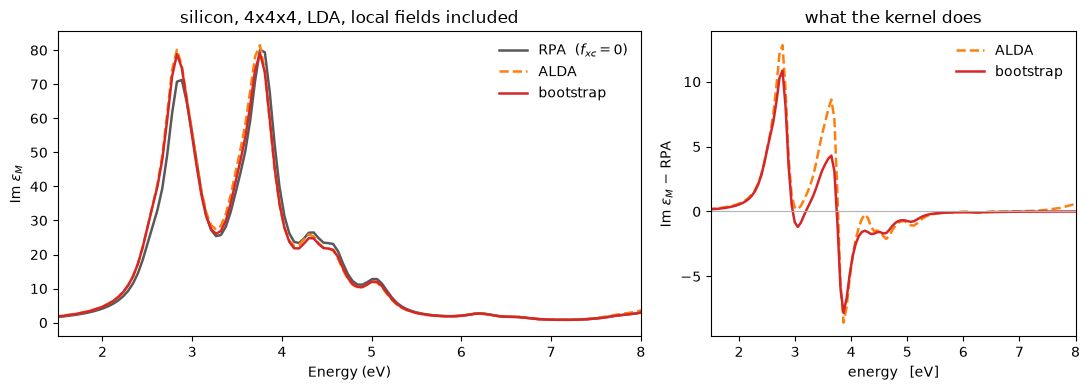

In [3]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.0), width_ratios=[1.6, 1])

STYLE = {"rpa": ("0.35", "-", r"RPA  ($f_{xc} = 0$)"),
         "alda": ("tab:orange", "--", "ALDA"),
         "bootstrap": ("tab:red", "-", "bootstrap")}
for kernel, (colour, dash, label) in STYLE.items():
    spectra[kernel].plot(ax=left, color=colour, ls=dash, lw=1.8, label=label)
    if kernel != "rpa":
        right.plot(OMEGA * RY_TO_EV,
                   spectra[kernel].absorption - spectra["rpa"].absorption, dash,
                   color=colour, lw=1.8, label=label)
left.set(xlim=(1.5, 8.0), title="silicon, 4x4x4, LDA, local fields included")
left.legend(frameon=False)
right.axhline(0.0, color="0.7", lw=0.8)
right.set(xlim=(1.5, 8.0), xlabel="energy   [eV]",
          ylabel=r"Im $\epsilon_M$ $-$ RPA", title="what the kernel does")
right.legend(frameon=False)
fig.tight_layout()

peak = int(np.argmax(spectra["rpa"].absorption))        # one cut, common to all three
for kernel in STYLE:
    curve = spectra[kernel].absorption
    print("%-11s weight below RPA's peak %.4f   first moment %.4f eV"
          % (kernel, curve[:peak].sum() / curve.sum(),
             (OMEGA * curve).sum() / curve.sum() * RY_TO_EV))

An attractive kernel moves oscillator strength **downhill**, towards the absorption edge, and
the first moment of the three spectra says so: 3.648 eV in RPA, 3.592 with ALDA, 3.587 with
the bootstrap. Silicon has no bound exciton, so there is no peak below the gap to find; what
shows here is the redistribution -- an enhanced $E_1$ shoulder at the expense of $E_2$ --
which is what the bootstrap paper's silicon panel shows.

**ALDA moves weight too, by about as much, and it would be wrong to say otherwise.** The
difference between the two is not visible in this figure and is not supposed to be: it is
the $\alpha$ column above, and it decides what happens in a material that *does* bind.

The energy window the weight is measured in has to be **common** to all three spectra.
Measuring each one below its own maximum moves the window with the spectrum and reverses the
answer.

## Two things that leave a perfectly plausible spectrum

**$\epsilon_M$ is the inverse of the $3\times3$ head of $\epsilon^{-1}$, not the head of the
inverse of the whole matrix.** The two are different physics: the second is exactly the
no-local-field result -- smooth, positive, with the right peaks, and 9% too large. Local
field effects are the difference between them, and the result carries both so the difference
can be looked at.

**Truncating the sum over empty bands has no symptom.** An undersized sum gives a spectrum
that looks entirely fine, which is why the residue against the band-complete static route is
reported. It has to be compared kernel for kernel and scissors for scissors, since
differencing two routes measures every way they differ: a 0.05 Ry scissors shift applied on
one side alone turns a residual of $+0.013$ into $-3.46$.

## What it refuses

Finite $\mathbf q$, ultrasoft and PAW datasets, metals, spin in any form, a symmetry-reduced
k-set, ALDA with a gradient-corrected functional, and a bootstrap fixed point that has not
converged. `TDDFPT/` is the closest thing QE has and it is not comparable: a
Liouville-Lanczos solver with RPA and ALDA, which has no bootstrap kernel and never forms a
Dyson equation in $\mathbf G$ space at all.

---
The tests behind this notebook: `tests/regression/test_tddft.py`, which holds the identity
between this sum over states and the Sternheimer solve of notebook 19 -- two routes to
$\epsilon_M(0)$ that share the ground state and nothing else -- and
`tests/unit/test_tddft_machinery.py`, which holds the head-of-the-inverse distinction and
the bootstrap's fixed point.